# $\color{#dda}{\text{Héctor Alonso Heredia Pérez}}$

# Análisis

## Análisis Descriptivo
- Realizar un análisis descriptivo de cada variable verificando:
  - Tipo de dato
  - Distribución
- Generar una comparación bivariada entre cada variable y la variable de respuesta `es_fraude`
- Realizar mean encoding para cada categoría en variables categóricas:
  - Propósito: Identificar qué variables pueden ser relevantes para predecir `es_fraude`
  - Conclusiones: [Incluir observaciones sobre las variables más relevantes]

## PCA (Análisis de Componentes Principales)
- Generar un PCA de 3 dimensiones y visualizarlo gráficamente
  - ¿Se observan clústers a simple vista?
- Descripción del PCA:
  - Qué es: Técnica de reducción de dimensionalidad
  - Cómo funciona: Transforma los datos a un nuevo sistema de coordenadas ordenado por varianza explicada
  - Utilidad: Para visualización, reducción de ruido y preprocesamiento

# Feature Engineering

## Generación de Nuevas Variables
1. **Variable 1**: [Nombre]
   - Hipótesis: [Explicación de por qué esta variable podría ser relevante]
   - Análisis bivariado con `es_fraude`
   - Conclusión: [¿Es útil o no?]

2. **Variable 2**: [Nombre]
   - Hipótesis: [Explicación de por qué esta variable podría ser relevante]
   - Análisis bivariado con `es_fraude`
   - Conclusión: [¿Es útil o no?]

# Encoding

## Método WoE (Weight of Evidence)
- Aplicar WoE para encoding de variables categóricas
- Descripción:
  - Cómo funciona: Transforma categorías en valores numéricos basados en la relación con la variable objetivo
  - Intuición matemática: Logaritmo del ratio entre distribución de eventos y no eventos
  - Interpretación: Valores positivos indican mayor asociación con fraude, negativos con no fraude

# Reducción de Variables

## Método Aplicado: [Seleccionar entre varianza, correlaciones o coeficientes de regresión logística]
- Teoría: [Explicación del método seleccionado]
- Utilidad: [Para qué sirve y cómo ayuda en el modelo]
- Resultados: [Variables eliminadas/mantenidas y justificación]

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

KeyboardInterrupt: 

In [ ]:
# Cargar el dataset
data = pd.read_csv('evaluacion_final.csv')

# $\color{#dda}{\text{Análisis descriptivo}}$

In [ ]:
data_info = data.describe(include='all')
data_types = data.dtypes
print(data_info)
print(data_types)

         Unnamed: 0      estatura estado_de_nacimiento  \
count   10000.00000  10000.000000                10000   
unique          NaN           NaN                    6   
top             NaN           NaN              Jalisco   
freq            NaN           NaN                 4925   
mean     4999.50000      1.603226                  NaN   
std      2886.89568      0.067391                  NaN   
min         0.00000      1.300000                  NaN   
25%      2499.75000      1.558184                  NaN   
50%      4999.50000      1.602361                  NaN   
75%      7499.25000      1.649776                  NaN   
max      9999.00000      1.850000                  NaN   

        tiempo_de_aplicacion_en_minutos       salario  \
count                      10000.000000  10000.000000   
unique                              NaN           NaN   
top                                 NaN           NaN   
freq                                NaN           NaN   
mean              

# $\color{#dda}{\text{Comparación bivariada}}$

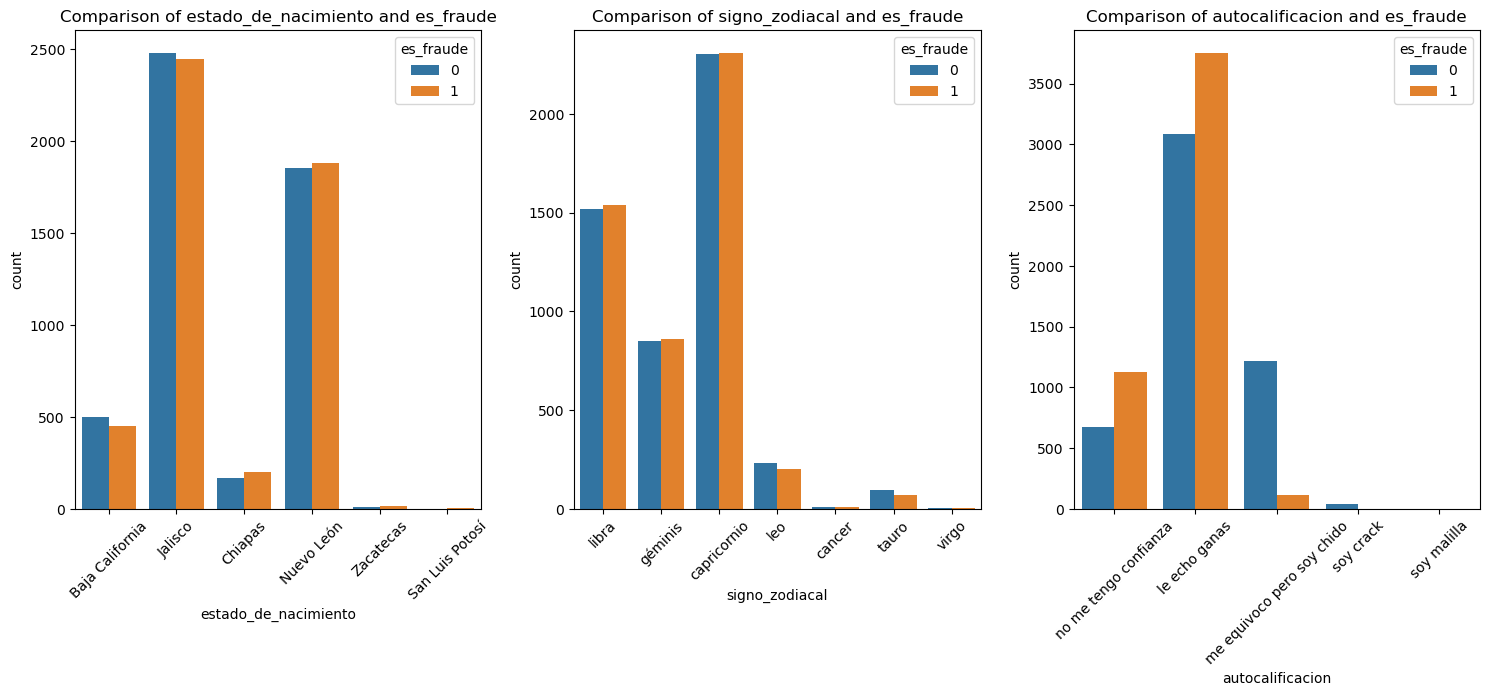

In [ ]:
categorical_columns = ['estado_de_nacimiento', 'signo_zodiacal', 'autocalificacion']
numerical_columns = ['estatura', 'tiempo_de_aplicacion_en_minutos', 'salario', 
                     'meses_de_existencia_del_email', 'antiguedad_de_linea_telefono_en_meses', 
                     'dependientes_economicos', 'edad']

# $\color{#dda}{\text{}}$

In [ ]:
# Gráficos de comparación bivariada para variables categóricas
plt.figure(figsize=(15, 12))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=data, x=column, hue='es_fraude')
    plt.title(f'Comparison of {column} and es_fraude')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# $\color{#dda}{\text{}}$

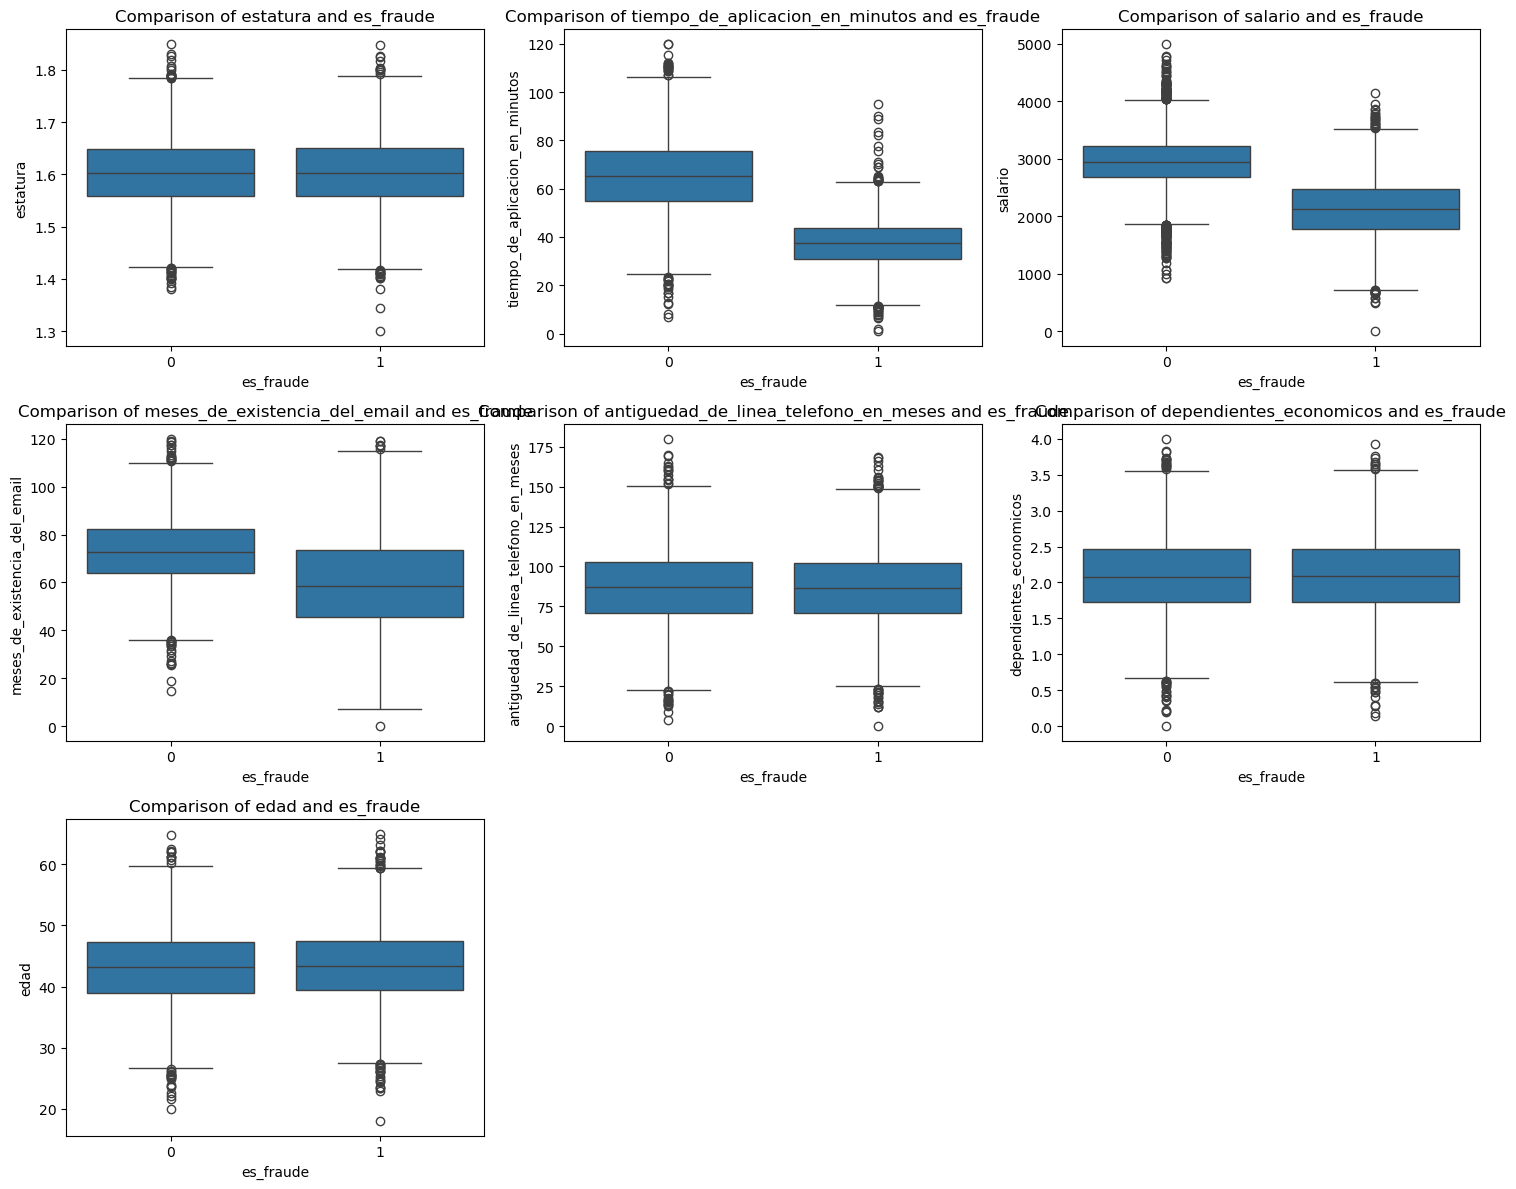

In [6]:
# Gráficos de comparación bivariada para variables numéricas
plt.figure(figsize=(15, 12))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=data, x='es_fraude', y=column)
    plt.title(f'Comparison of {column} and es_fraude')
plt.tight_layout()
plt.show()

# $\color{#dda}{\text{}}$

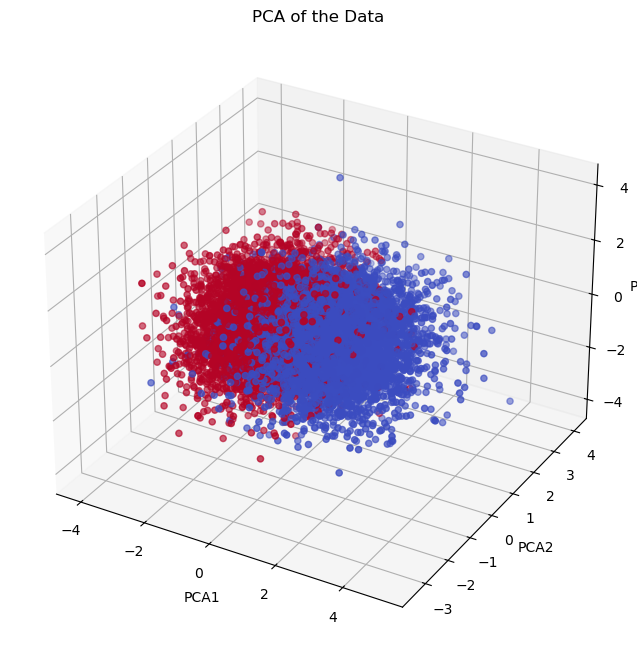

In [7]:
# Realizar un PCA de 3 dimensiones

# Selección de variables numéricas
numerical_data = data[numerical_columns]
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

# PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(numerical_scaled)

# Crear DataFrame con los resultados de PCA
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['es_fraude'] = data['es_fraude']

# Graficar PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PCA1'], pca_df['PCA2'], pca_df['PCA3'], c=pca_df['es_fraude'], cmap='coolwarm')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.title('PCA of the Data')
plt.show()

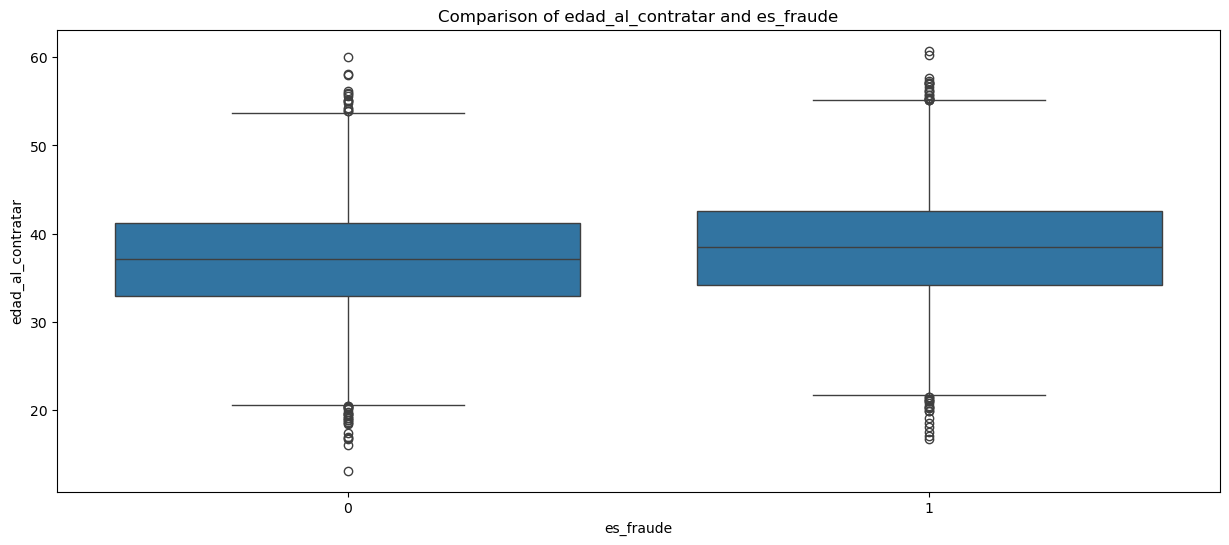

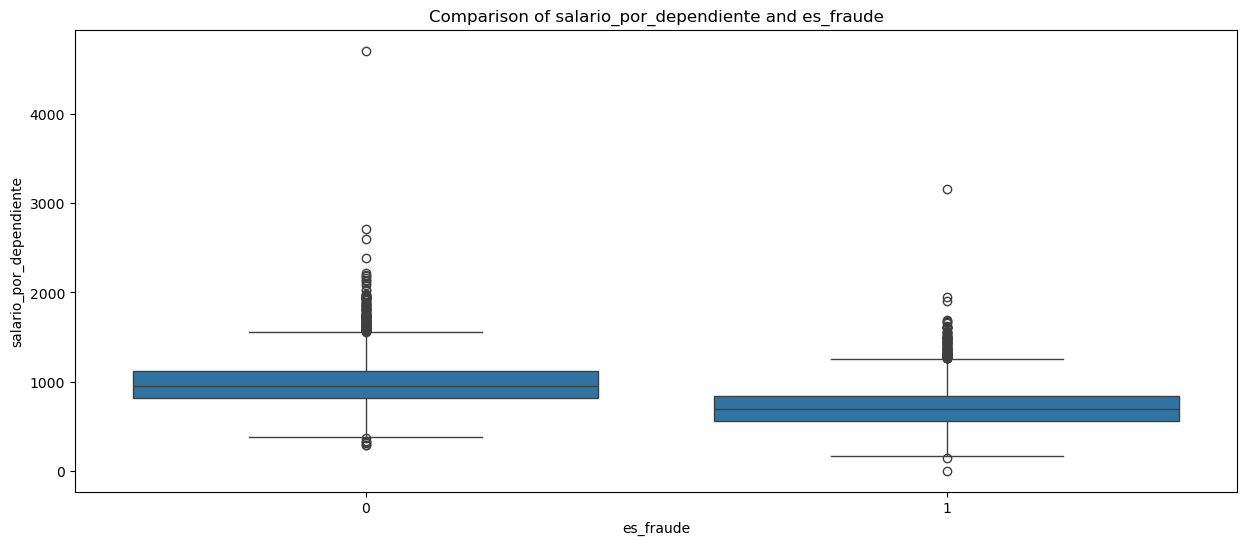

In [8]:
# Feature engineering
# Generación de dos nuevas variables (ejemplo)
data['edad_al_contratar'] = data['edad'] - data['meses_de_existencia_del_email'] / 12
data['salario_por_dependiente'] = data['salario'] / (data['dependientes_economicos'] + 1)

# Análisis bivariado de las nuevas variables con 'es_fraude'
plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='es_fraude', y='edad_al_contratar')
plt.title('Comparison of edad_al_contratar and es_fraude')
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='es_fraude', y='salario_por_dependiente')
plt.title('Comparison of salario_por_dependiente and es_fraude')
plt.show()

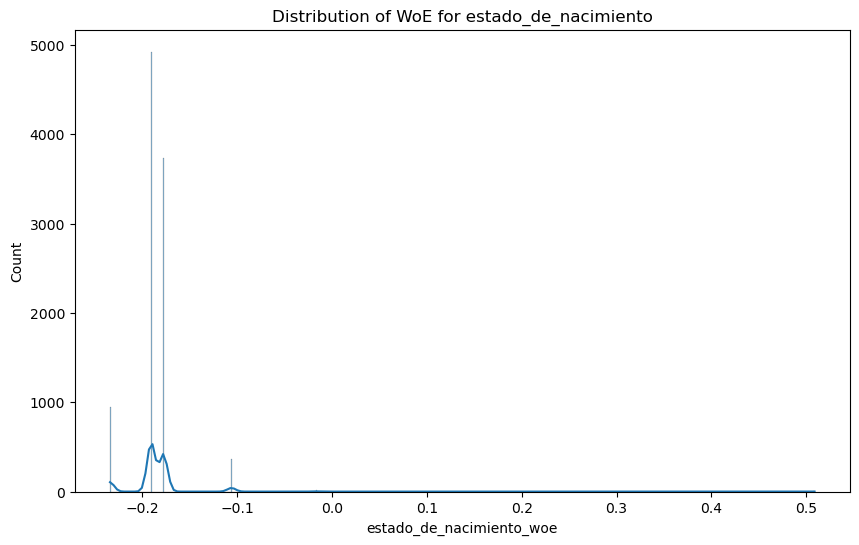

In [9]:
# Aplicar WoE para encodear variables categóricas

# Definir una función de WoE
def woE_encoding(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['mean', 'count'])
    grouped['woe'] = np.log(grouped['mean'] / grouped['mean'].mean())
    return grouped['woe'].to_dict()

# Aplicar WoE al 'estado_de_nacimiento' como ejemplo
woe_dict = woE_encoding(data, 'estado_de_nacimiento', 'es_fraude')
data['estado_de_nacimiento_woe'] = data['estado_de_nacimiento'].map(woe_dict)

# Mostrar la distribución del WoE
plt.figure(figsize=(10, 6))
sns.histplot(data['estado_de_nacimiento_woe'], kde=True)
plt.title('Distribution of WoE for estado_de_nacimiento')
plt.show()

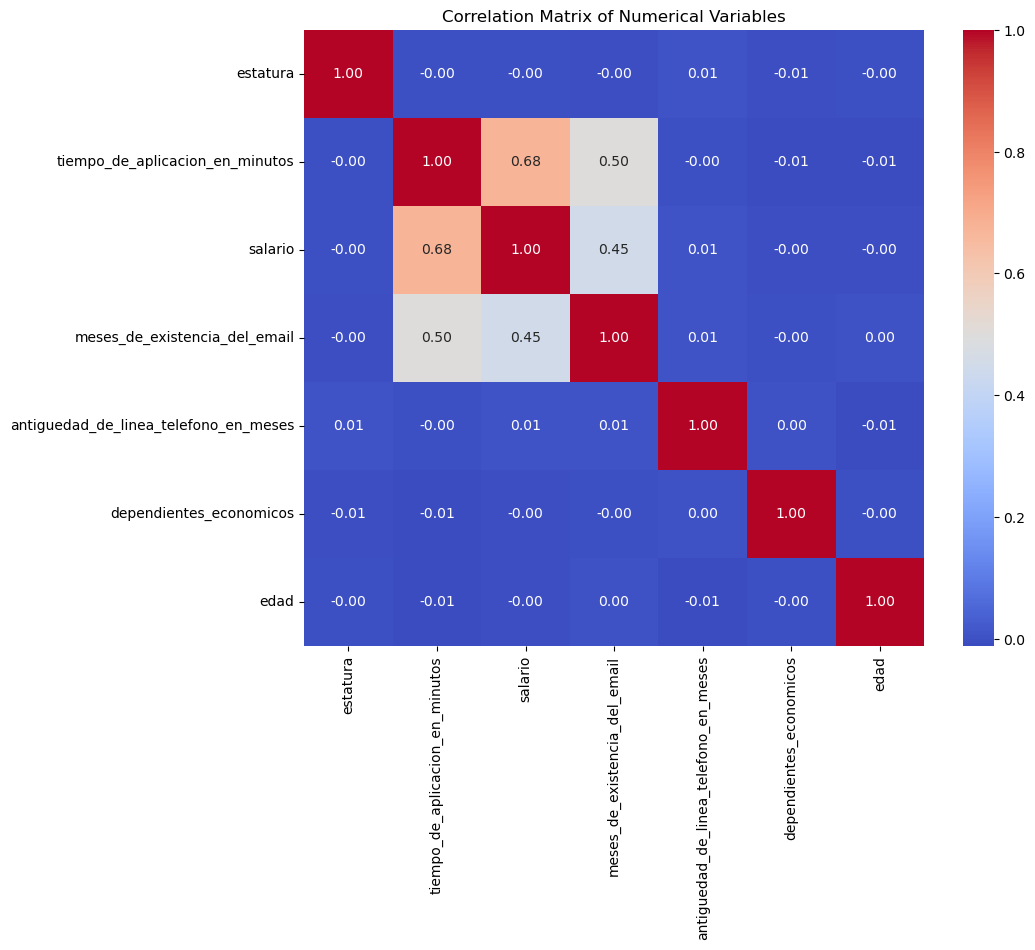

In [10]:
# Reducción de variables (utilizando correlaciones)
corr_matrix = data[numerical_columns].corr()

# Mostrar la matriz de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [11]:
# Selección de variables altamente correlacionadas
# Eliminar variables con alta correlación (mayor que 0.9)
high_corr_var = np.where(corr_matrix > 0.9)
high_corr_var = [(numerical_columns[x], numerical_columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

print("Highly correlated variables:", high_corr_var)

Highly correlated variables: []
